# Анализ датасета Data Science Salaries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.options.display.max_columns = None
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
url = 'https://raw.githubusercontent.com/SatyaYuga13/data-science-salaries-project-/refs/heads/main/ds_salaries.csv'

df = pd.read_csv(url)

print(df.head())
print(f"Загружено {len(df)} строк")

   work_year experience_level employment_type                 job_title  \
0       2023               SE              FT  Principal Data Scientist   
1       2023               MI              CT               ML Engineer   
2       2023               MI              CT               ML Engineer   
3       2023               SE              FT            Data Scientist   
4       2023               SE              FT            Data Scientist   

   salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0   80000             EUR          85847                 ES           100   
1   30000             USD          30000                 US           100   
2   25500             USD          25500                 US           100   
3  175000             USD         175000                 CA           100   
4  120000             USD         120000                 CA           100   

  company_location company_size  
0               ES            L  
1               US

In [ ]:
df.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
5,2023,SE,FT,Applied Scientist,222200,USD,222200,US,0,US,L
6,2023,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L
7,2023,SE,FT,Data Scientist,219000,USD,219000,CA,0,CA,M
8,2023,SE,FT,Data Scientist,141000,USD,141000,CA,0,CA,M
9,2023,SE,FT,Data Scientist,147100,USD,147100,US,0,US,M


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2584 entries, 0 to 3754
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   work_year                2584 non-null   int64   
 1   experience_level         2584 non-null   object  
 2   employment_type          2584 non-null   object  
 3   job_title                2584 non-null   object  
 4   salary                   2584 non-null   int64   
 5   salary_currency          2584 non-null   object  
 6   salary_in_usd            2584 non-null   int64   
 7   employee_residence       2584 non-null   object  
 8   remote_ratio             2584 non-null   int64   
 9   company_location         2584 non-null   object  
 10  company_size             2584 non-null   object  
 11  experience_level_name    2584 non-null   category
 12  employment_type_name     2584 non-null   object  
 13  company_size_name        2584 non-null   object  
 14  company_locat

Датасет содержит 3755 строк и 11 столбцов.

Признаки включают информацию о годе работы, уровне опыта, типе занятости, должности, заработной плате, валюте, стране проживания сотрудника, формате работы, а также характеристиках компании.

Типы данных представлены числовыми (int64) и категориальными (object) признаками, что позволяет проводить как количественный, так и категориальный анализ.

In [ ]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


В датасете отсутствуют пропущенные значения во всех столбцах.

Таким образом, дополнительная обработка пропусков не требуется, и данные можно использовать для анализа без предварительной очистки.

In [ ]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


Анализ описательной статистики показывает, что медианная заработная плата составляет около 135,000 USD, при этом среднее значение выше (~137,500 USD), что может указывать на наличие высоких значений (выбросов).

Минимальная заработная плата составляет около 5,132 USD, тогда как максимальная достигает 450,000 USD, что подтверждает наличие значительного разброса данных.

Также можно заметить, что большинство наблюдений приходится на 2022–2023 годы, что делает анализ актуальным для текущего рынка труда.

In [ ]:
df.duplicated().sum()

np.int64(1171)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

В датасете были обнаружены дубликаты, которые были удалены для предотвращения искажения результатов анализа.

После удаления дубликатов данные стали более корректными и пригодными для дальнейшего анализа.

In [ ]:
# Словари для уровня опыта, типа занятости, размера компании, стран компании и сотрудников
exp_map = {
    'EN': 'Junior',
    'MI': 'Middle',
    'SE': 'Senior',
    'EX': 'Executive'
}

emp_map = {
    'FT': 'Full-time',
    'PT': 'Part-time',
    'CT': 'Contract',
    'FL': 'Freelance'
}

size_map = {
    'S': 'Small',
    'M': 'Medium',
    'L': 'Large'
}

company_country_map = {
    'US': 'United States',
    'GB': 'United Kingdom',
    'CA': 'Canada',
    'IN': 'India',
    'DE': 'Germany',
    'ES': 'Spain',
    'FR': 'France',
    'BR': 'Brazil',
    'AU': 'Australia',
    'PT': 'Portugal',
    'NL': 'Netherlands',
    'GR': 'Greece',
    'IL': 'Israel'
}

employee_country_map = {
    'US': 'United States',
    'GB': 'United Kingdom',
    'CA': 'Canada',
    'IN': 'India',
    'DE': 'Germany',
    'ES': 'Spain',
    'FR': 'France',
    'BR': 'Brazil',
    'AU': 'Australia',
    'PT': 'Portugal',
    'NL': 'Netherlands',
    'GR': 'Greece',
    'IL': 'Israel'
}

df['experience_level_name'] = df['experience_level'].map(exp_map)
df['employment_type_name'] = df['employment_type'].map(emp_map)
df['company_size_name'] = df['company_size'].map(size_map)
df['company_location_name'] = df['company_location'].map(company_country_map).fillna(df['company_location'])
df['employee_residence_name'] = df['employee_residence'].map(employee_country_map).fillna(df['employee_residence'])

In [ ]:
order = ['Junior', 'Middle', 'Senior', 'Executive']

df['experience_level_name'] = pd.Categorical(
    df['experience_level_name'],
    categories=order,
    ordered=True
)

## Анализ самых высокооплачиваемых должностей и выбросов в заработной плате

In [ ]:
# Группировка по должностям: средняя зарплата и количество наблюдений
job_stats = df.groupby('job_title')['salary_in_usd'].agg(['mean', 'median', 'count'])
# Сортировка по средней зарплате
job_stats.sort_values(by='mean', ascending=False).head(10)

,mean,median,count
job_title,,,
Data Science Tech Lead,375000.000000,375000.0,1
Cloud Data Architect,250000.000000,250000.0,1
Data Lead,212500.000000,212500.0,2
Data Analytics Lead,211254.500000,211254.5,2
Principal Data Scientist,198171.125000,164630.5,8
Director of Data Science,195140.727273,168000.0,11
Principal Data Engineer,192500.000000,192500.0,2
Machine Learning Software Engineer,192420.000000,181800.0,10
Applied Scientist,190342.580645,192000.0,31


Первичный анализ показал, что некоторые должности имеют крайне высокие значения заработной платы.

Однако часть из них представлена в датасете в небольшом количестве, что может искажать результаты.

В связи с этим необходимо учитывать количество наблюдений для получения более репрезентативной картины.

In [ ]:
# Фильтрация: оставляем только должности с количеством наблюдений >= 10
job_stats_filtered = job_stats[job_stats['count'] >= 10]

# Топ-10 по средней зарплате
top_jobs_filtered = job_stats_filtered.sort_values(by='mean', ascending=False)

top_jobs_filtered.head(10)

,mean,median,count
job_title,,,
Director of Data Science,195140.727273,168000.0,11
Machine Learning Software Engineer,192420.000000,181800.0,10
Applied Scientist,190342.580645,192000.0,31
Head of Data,183857.500000,202500.0,10
Data Science Manager,181930.173077,175100.0,52
Data Architect,167751.453125,163750.0,64
Research Engineer,165909.393939,155000.0,33
Machine Learning Scientist,163220.076923,167875.0,26
ML Engineer,158352.441176,160000.0,34


Для получения более корректной и репрезентативной картины был применён фильтр по количеству наблюдений (не менее 10).

В результате наиболее высокооплачиваемыми должностями являются:

- Director of Data Science
- Machine Learning Software Engineer
- Applied Scientist
- Head of Data
- Data Science Manager

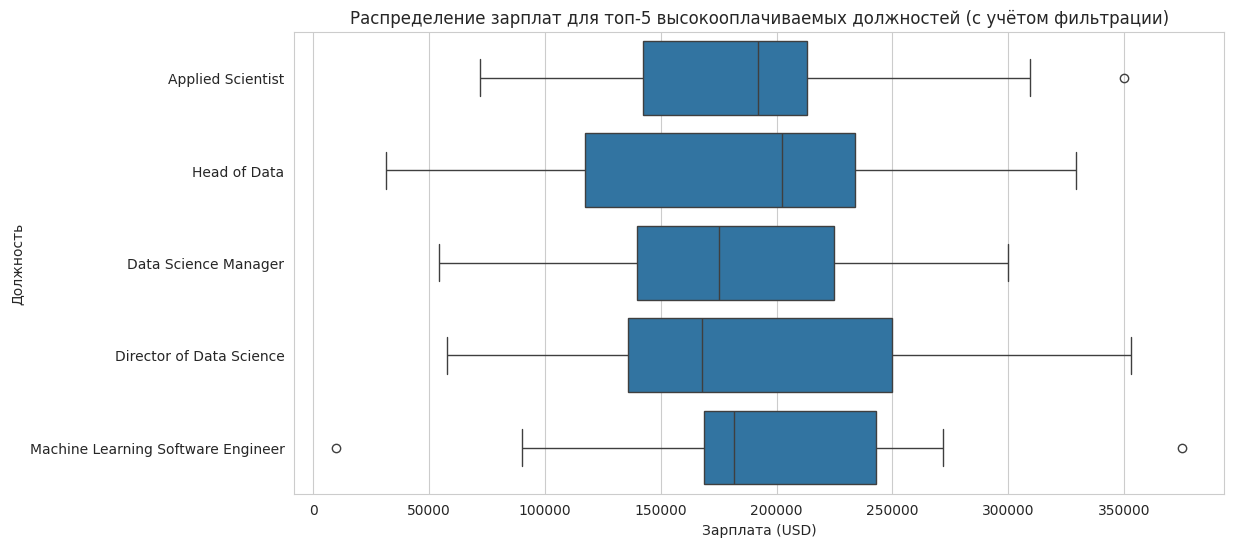

In [ ]:
top_5_titles = top_jobs_filtered.head(5).index

df_top = df[df['job_title'].isin(top_5_titles)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, y='job_title', x='salary_in_usd', orient='h')

plt.title('Распределение зарплат для топ-5 высокооплачиваемых должностей (с учётом фильтрации)')
plt.xlabel('Зарплата (USD)')
plt.ylabel('Должность')

plt.show()

На графике представлены распределения заработных плат для топ-5 наиболее высокооплачиваемых должностей после фильтрации.

Можно заметить, что даже среди данных ролей наблюдается значительный разброс значений, что связано с различиями в уровне опыта, компаниях и условиях работы.

In [ ]:
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['salary_in_usd'] < lower_bound) |
                 (df['salary_in_usd'] > upper_bound)]

In [ ]:
df_outliers['job_title'].value_counts().head(10)

,count
job_title,
Data Scientist,4
Machine Learning Engineer,3
Research Scientist,3
Data Analyst,2
Data Architect,2
Director of Data Science,2
Data Engineer,2
Computer Vision Engineer,1
AI Scientist,1


In [ ]:
df_outliers.sort_values(by='salary_in_usd', ascending=False).head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_name,employment_type_name,company_size_name,company_location_name,employee_residence_name
3522,2020,MI,FT,Research Scientist,450000,USD,450000,US,0,US,M,Middle,Full-time,Medium,United States,United States
2011,2022,MI,FT,Data Analyst,350000,GBP,430967,GB,0,GB,M,Middle,Full-time,Medium,United Kingdom,United Kingdom
528,2023,SE,FT,AI Scientist,1500000,ILS,423834,IL,0,IL,L,Senior,Full-time,Large,Israel,Israel
3747,2021,MI,FT,Applied Machine Learning Scientist,423000,USD,423000,US,50,US,L,Middle,Full-time,Large,United States,United States
3675,2021,EX,CT,Principal Data Scientist,416000,USD,416000,US,100,US,S,Executive,Contract,Small,United States,United States
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L,Senior,Full-time,Large,United States,United States
3463,2022,SE,FT,Data Analytics Lead,405000,USD,405000,US,100,US,L,Senior,Full-time,Large,United States,United States
1288,2023,SE,FT,Data Analyst,385000,USD,385000,US,0,US,M,Senior,Full-time,Medium,United States,United States
3468,2022,SE,FT,Applied Data Scientist,380000,USD,380000,US,100,US,L,Senior,Full-time,Large,United States,United States
649,2023,SE,FT,Data Architect,376080,USD,376080,US,100,US,M,Senior,Full-time,Medium,United States,United States


In [ ]:
df_outliers.sort_values(by='salary_in_usd').head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_name,employment_type_name,company_size_name,company_location_name,employee_residence_name
1396,2023,EX,FT,Head of Data Science,314100,USD,314100,US,0,US,M,Executive,Full-time,Medium,United States,United States
2406,2022,SE,FT,Data Engineer,315000,USD,315000,US,100,US,M,Senior,Full-time,Medium,United States,United States
488,2023,SE,FT,Data Scientist,317070,USD,317070,US,0,US,M,Senior,Full-time,Medium,United States,United States
145,2023,SE,FT,Machine Learning Engineer,318300,USD,318300,US,100,US,M,Senior,Full-time,Medium,United States,United States
1116,2023,SE,FT,Machine Learning Engineer,323300,USD,323300,US,0,US,M,Senior,Full-time,Medium,United States,United States
3410,2022,EX,FT,Data Engineer,324000,USD,324000,US,100,US,M,Executive,Full-time,Medium,United States,United States
3697,2020,EX,FT,Director of Data Science,325000,USD,325000,US,100,US,L,Executive,Full-time,Large,United States,United States
228,2023,EX,FT,Head of Data,329500,USD,329500,US,0,US,M,Executive,Full-time,Medium,United States,United States
845,2023,MI,FT,Research Scientist,340000,USD,340000,US,100,US,M,Middle,Full-time,Medium,United States,United States
133,2023,SE,FT,Machine Learning Engineer,342300,USD,342300,US,0,US,L,Senior,Full-time,Large,United States,United States


In [ ]:
len(df_outliers)
print(f"Количество выбросов: {len(df_outliers)}")

Количество выбросов: 29


In [ ]:
df['salary_in_usd'].describe()

,salary_in_usd
count,2584.000000
mean,133409.280186
std,67136.837329
min,5132.000000
25%,84975.000000
50%,130000.000000
75%,175000.000000
max,450000.000000


В ходе анализа были выявлены выбросы в заработной плате с использованием метода межквартильного размаха (IQR).

Нижние выбросы отсутствуют, так как минимальные значения не выходят за допустимые границы.

При этом обнаружены верхние выбросы — значения, превышающие ~295,000 USD.

Наибольшее количество выбросов наблюдается в следующих должностях:

Data Scientist
Machine Learning Engineer
Research Scientist

Это может быть связано с наличием высокооплачиваемых senior и lead позиций, а также работой в крупных компаниях.

In [ ]:
df.groupby('experience_level')['salary_in_usd'].median()

,salary_in_usd
experience_level,
EN,61900.0
EX,189618.5
MI,95000.0
SE,148800.0


In [ ]:
# Подсчёт количества специалистов по уровням опыта
exp_counts = pd.pivot_table(
    df,
    index='job_title',
    columns='experience_level_name',
    values='salary_in_usd',
    aggfunc='count',
    fill_value=0
).reset_index()

# Объединяем с основной таблицей
final_table = job_stats_filtered.merge(
    exp_counts,
    on='job_title',
    how='left'
)
# фикс для отсутствующих колонок
for col in order:
    if col not in final_table.columns:
        final_table[col] = 0

# Топ-10
top10 = final_table.sort_values(by='median', ascending=False).head(10)
top10

,job_title,mean,median,count,Junior,Middle,Senior,Executive
21,Head of Data,183857.500000,202500.0,10,0,1,3,6
5,Applied Scientist,190342.580645,192000.0,31,4,0,27,0
26,Machine Learning Software Engineer,192420.000000,181800.0,10,1,0,9,0
10,Computer Vision Engineer,143536.111111,177295.0,18,4,2,12,0
17,Data Science Manager,181930.173077,175100.0,52,0,8,39,5
24,Machine Learning Infrastructure Engineer,143011.818182,171600.0,11,0,4,7,0
20,Director of Data Science,195140.727273,168000.0,11,0,0,3,8
25,Machine Learning Scientist,163220.076923,167875.0,26,2,11,11,2
13,Data Architect,167751.453125,163750.0,64,0,5,57,2
22,ML Engineer,158352.441176,160000.0,34,2,11,21,0


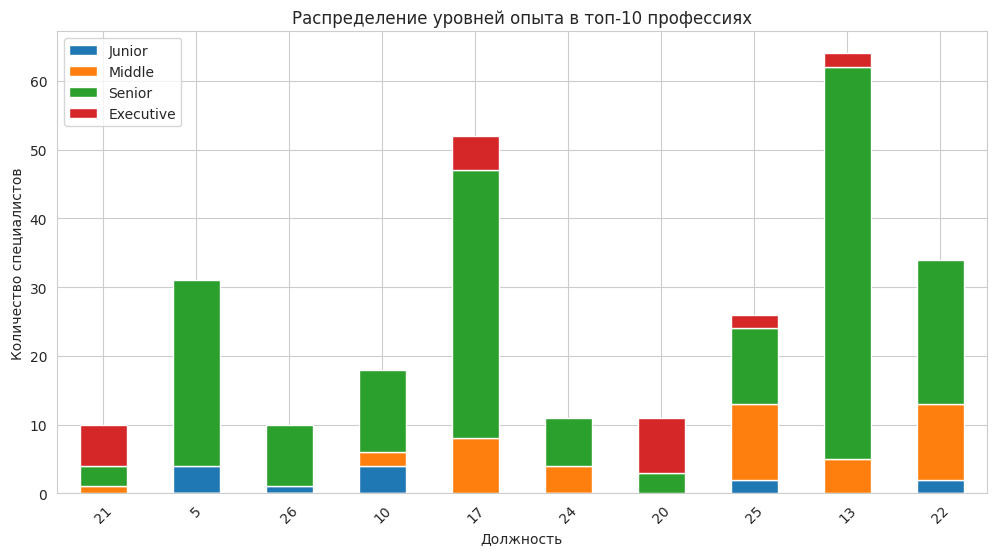

In [ ]:
top10[['Junior', 'Middle', 'Senior', 'Executive']].plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Распределение уровней опыта в топ-10 профессиях')
plt.xlabel('Должность')
plt.ylabel('Количество специалистов')

plt.xticks(rotation=45)
plt.show()

Дополнительно был проведён анализ распределения уровней опыта среди наиболее высокооплачиваемых профессий.

Было выявлено, что в данных ролях преобладают специалисты уровня Senior (SE), а также присутствует доля Executive (EX).

Это объясняет высокий уровень заработных плат, так как данные позиции требуют значительного опыта и экспертизы.

Таким образом, высокая заработная плата обусловлена не только самой должностью, но и уровнем квалификации специалистов.

## Анализ удалённого формата работы

In [ ]:
df['remote_ratio'].unique()

array([100,   0,  50])

In [ ]:
df.groupby('remote_ratio')['salary_in_usd'].agg(['mean', 'median', 'count'])

,mean,median,count
remote_ratio,,,
0,143690.173693,137500.0,1186
50,78486.609626,63312.0,187
100,131821.666391,130000.0,1211


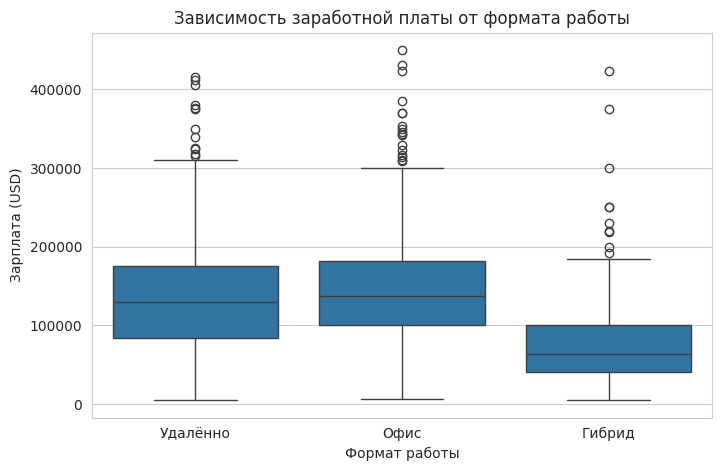

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df['remote_ratio'].map({0: 'Офис', 50: 'Гибрид', 100: 'Удалённо'}),
    y='salary_in_usd',
    data=df
)

plt.title('Зависимость заработной платы от формата работы')
plt.xlabel('Формат работы')
plt.ylabel('Зарплата (USD)')
plt.show()

In [ ]:
df.groupby(['remote_ratio', 'experience_level_name'])['salary_in_usd'].median()

remote_ratio  experience_level_name
0             Junior                    90000.0
              Middle                   105380.0
              Senior                   150000.0
              Executive                181080.0
50            Junior                    49823.0
              Middle                    62726.0
              Senior                    91935.0
              Executive                128001.0
100           Junior                    57000.0
              Middle                    89327.0
              Senior                   150000.0
              Executive                200000.0
Name: salary_in_usd, dtype: float64

In [ ]:
df['remote_ratio'].value_counts()

,count
remote_ratio,
100,1211
0,1186
50,187


Первичный анализ показал, что сотрудники, работающие в офисе, имеют более высокую заработную плату по сравнению с удалённым форматом.
Однако дополнительный анализ с учётом уровня опыта показал, что данное различие во многом обусловлено распределением сотрудников по уровням квалификации.

При сравнении внутри одного уровня опыта (например, Senior) разница в заработной плате между офисным и удалённым форматом практически отсутствует.

Таким образом, формат работы сам по себе не оказывает существенного влияния на уровень заработной платы, а ключевым фактором является уровень опыта специалиста.

Стоит отметить, что гибридный формат демонстрирует более низкие значения заработной платы, однако данный результат может быть менее надёжным из-за относительно небольшого количества наблюдений.

## Анализ размера компании

In [ ]:
df.groupby("company_size_name")["salary_in_usd"].agg(['mean', 'median', 'count'])

,mean,median,count
company_size_name,,,
Large,113202.239609,100000.0,409
Medium,141474.514300,137067.5,2028
Small,78364.278912,62726.0,147


In [ ]:
df.groupby(['company_size_name', 'experience_level_name'])['salary_in_usd'].agg(['median', 'count'])

median  count
company_size_name experience_level_name                 
Large             Junior                  58551.0     96
                  Middle                  81264.0    132
                  Senior                 146350.0    168
                  Executive              150000.0     13
Medium            Junior                  70000.0    125
                  Middle                 100000.0    483
                  Senior                 150000.0   1343
                  Executive              195800.0     77
Small             Junior                  52008.0     49
                  Middle                  58000.0     49
                  Senior                  91237.0     43
                  Executive              190000.0      6

Text(0, 0.5, 'Зарплата (USD)')

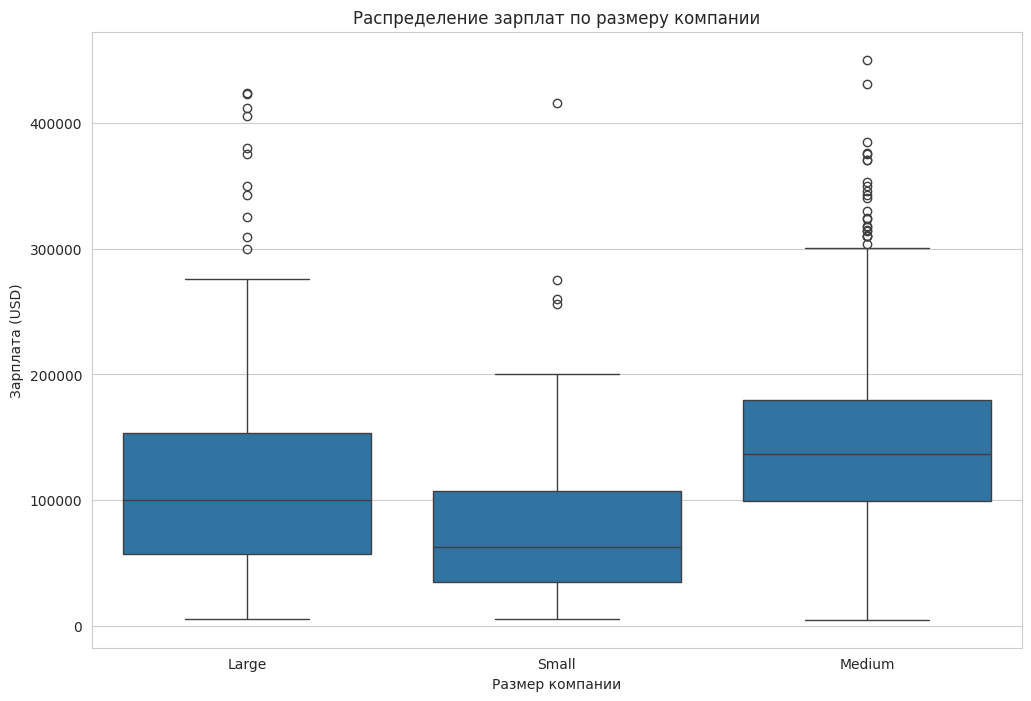

In [ ]:
# Визуализация медианных значений заработной платы по размеру компании
sns.boxplot(data=df, x='company_size_name', y='salary_in_usd')
plt.title('Распределение зарплат по размеру компании')
plt.xlabel('Размер компании')
plt.ylabel('Зарплата (USD)')

Text(0, 0.5, 'Зарплата (USD)')

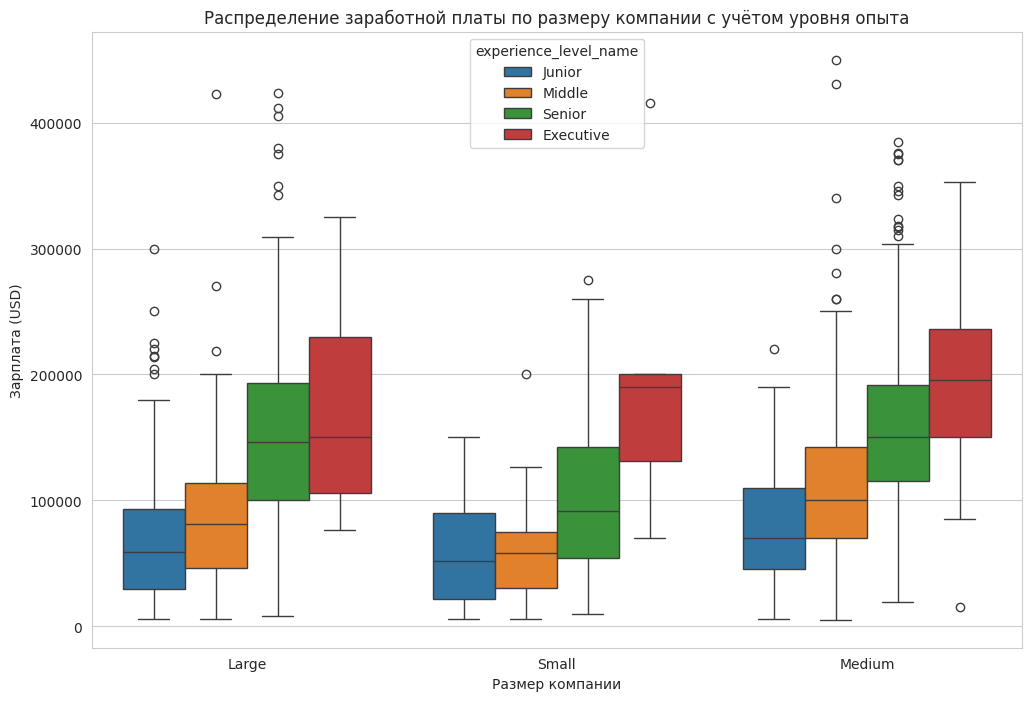

In [ ]:
# Визуализация медианных значений заработной платы по размеру компании с разбивкой по опыту
sns.boxplot(data=df, x='company_size_name', y='salary_in_usd', hue='experience_level_name')
plt.title('Распределение заработной платы по размеру компании с учётом уровня опыта')
plt.xlabel('Размер компании')
plt.ylabel('Зарплата (USD)')

Text(0, 0.5, 'Зарплата (USD)')

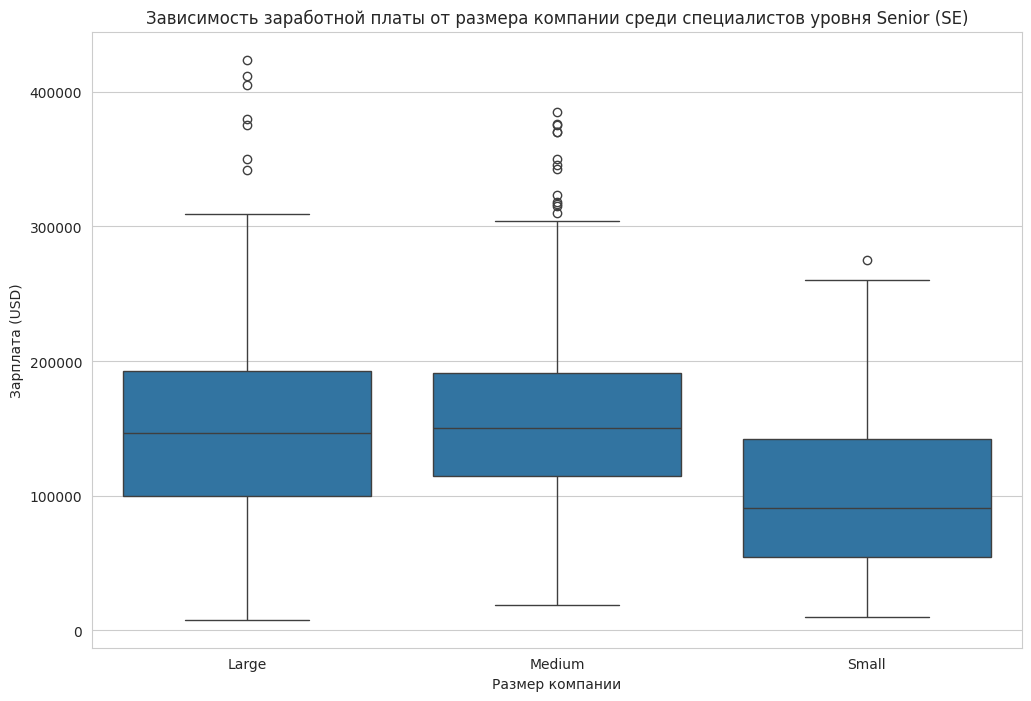

In [ ]:
# Визуализация медианных значений заработной платы по размеру компании с разбивкой по опыту (только SE)
df_se = df[df['experience_level_name'] == 'Senior']

sns.boxplot(data=df_se, x='company_size_name', y='salary_in_usd')
plt.title('Зависимость заработной платы от размера компании среди специалистов уровня Senior (SE)')
plt.xlabel('Размер компании')
plt.ylabel('Зарплата (USD)')

Первичный анализ показал, что уровень заработной платы различается в зависимости от размера компании: сотрудники средних компаний (M) в среднем зарабатывают больше, чем сотрудники крупных (L) и малых (S) компаний.

Для уточнения данного наблюдения был проведён дополнительный анализ с учётом уровня опыта сотрудников. Результаты показали, что данная тенденция сохраняется внутри всех уровней квалификации (EN, MI, SE), что снижает вероятность того, что различия обусловлены только распределением опыта.

Дополнительный анализ среди специалистов уровня Senior (SE) подтвердил, что сотрудники малых компаний получают существенно меньше, чем их коллеги из средних и крупных компаний.

Таким образом, можно предположить, что размер компании связан с уровнем заработной платы. При этом следует учитывать, что на результаты могут влиять и другие факторы, такие как должность сотрудников и страна расположения компании.

Наиболее высокие значения наблюдаются в средних компаниях, что может быть связано с их активным ростом и необходимостью привлекать квалифицированных специалистов в условиях конкуренции на рынке.

## Анализ наиболее популярных стран среди вакансий

In [ ]:
# Самые популярные страны по количеству вакансий
df['company_location_name'].value_counts().head(10).to_frame(name='count')

,count
company_location_name,
United States,1929
United Kingdom,155
Canada,83
India,57
Germany,55
Spain,44
France,33
Brazil,15
Australia,14


Наиболее популярными странами по количеству вакансий являются:

- United States
- United Kingdom
- Canada
- India
- Germany
- Spain
- France
- Brazil
- Australia
- Portugal

Это связано с высокой концентрацией IT-компаний и развитым рынком Data Science в данных регионах.

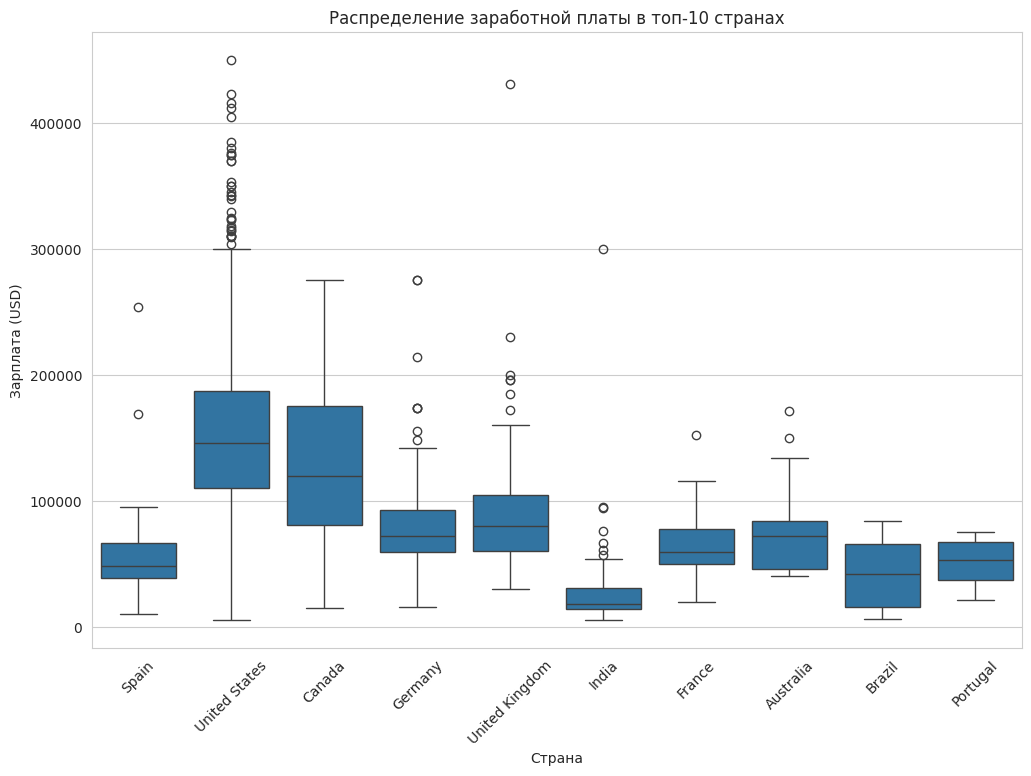

In [ ]:
top_countries = df['company_location_name'].value_counts().head(10).index
df_top = df[df['company_location_name'].isin(top_countries)]

sns.boxplot(data=df_top, x='company_location_name', y='salary_in_usd')

plt.title('Распределение заработной платы в топ-10 странах')
plt.xlabel('Страна')
plt.ylabel('Зарплата (USD)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
company_location = df.groupby('company_location_name')['salary_in_usd'].agg(['mean', 'median', 'count'])

In [ ]:
company_location_filtered = company_location[company_location['count'] >= 10]

In [ ]:
company_location_filtered.sort_values(by='median', ascending=False).head(10)

,mean,median,count
company_location_name,,,
United States,152374.791602,145885.0,1929
Canada,130572.759036,120000.0,83
United Kingdom,87685.000000,80036.0,155
Netherlands,78738.307692,73546.0,13
Australia,80033.428571,72525.0,14
Germany,88244.345455,71897.0,55
MX,97151.100000,66000.0,10
France,66551.030303,59102.0,33
Portugal,50538.714286,52932.5,14


In [ ]:
company_location_filtered.sort_values(by='median', ascending=True).head(10)

,mean,median,count
company_location_name,,,
India,30490.807018,18314.0,57
Brazil,40579.200000,42000.0,15
Greece,46814.818182,47280.0,11
Spain,58224.204545,48289.0,44
Portugal,50538.714286,52932.5,14
France,66551.030303,59102.0,33
MX,97151.100000,66000.0,10
Germany,88244.345455,71897.0,55
Australia,80033.428571,72525.0,14


In [ ]:
df_se = df_top[df_top['experience_level'] == 'SE']

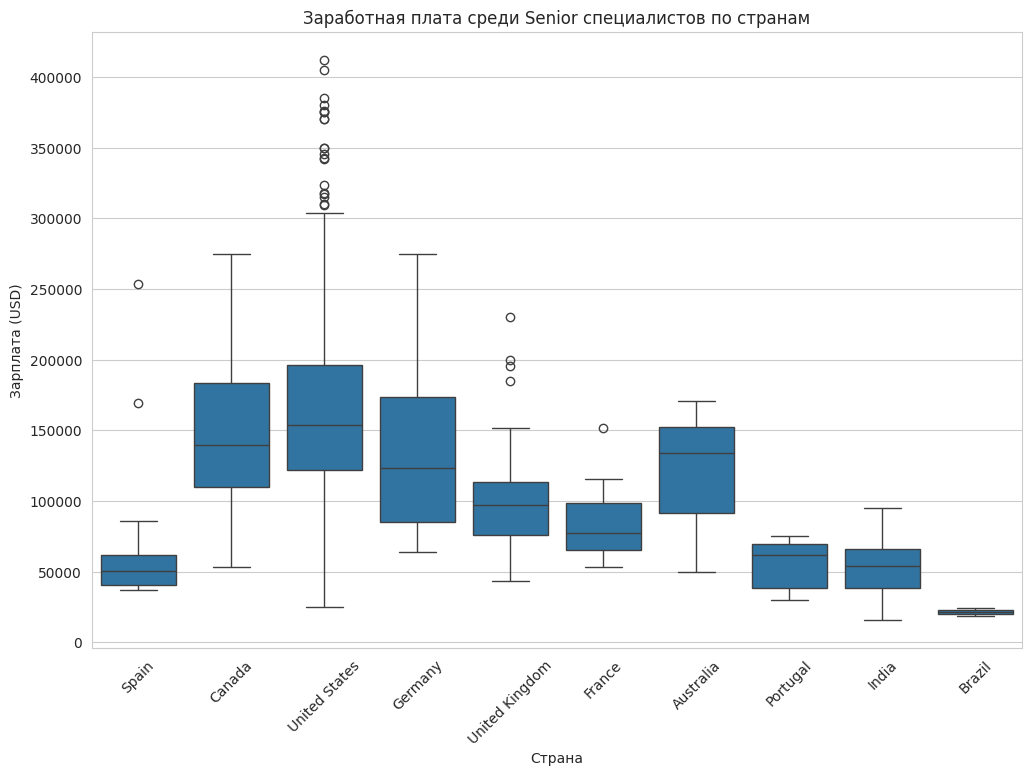

In [ ]:
sns.boxplot(data=df_se, x='company_location_name', y='salary_in_usd')

plt.title('Заработная плата среди Senior специалистов по странам')
plt.xlabel('Страна')
plt.ylabel('Зарплата (USD)')
plt.xticks(rotation=45)
plt.show()

Для анализа заработных плат была проведена группировка по странам с учётом фильтрации по количеству наблюдений (не менее 10), что позволило исключить нерепрезентативные значения.

Результаты показали, что наиболее высокие медианные заработные платы наблюдаются в таких странах, как United States, Canada, United Kingdom, Netherlands и Australia.
В то же время, наиболее низкие значения зафиксированы в India, Brazil, Greece, Spain и Portugal.

Для проверки влияния уровня опыта был проведён дополнительный анализ среди специалистов уровня Senior (SE). Он показал, что разница в заработной плате между странами сохраняется, а United States остаются лидером даже при фиксированном уровне квалификации.

Это свидетельствует о том, что страна компании оказывает существенное влияние на уровень заработной платы независимо от опыта сотрудника.

Данные различия могут быть обусловлены уровнем развития рынка, концентрацией технологических компаний и экономическими факторами, включая уровень инвестиций в IT и стоимость жизни.

## Анализ медианной заработной платы по должностям

In [ ]:
median_salary = df.groupby('job_title')['salary_in_usd'].agg(['median', 'count'])

In [ ]:
median_salary_filtered = median_salary[median_salary['count'] >= 10]

In [ ]:
median_salary_filtered.sort_values(by='median', ascending=False).head(30)

,median,count
job_title,,
Head of Data,202500.0,10
Applied Scientist,192000.0,31
Machine Learning Software Engineer,181800.0,10
Computer Vision Engineer,177295.0,18
Data Science Manager,175100.0,52
Machine Learning Infrastructure Engineer,171600.0,11
Director of Data Science,168000.0,11
Machine Learning Scientist,167875.0,26
Data Architect,163750.0,64


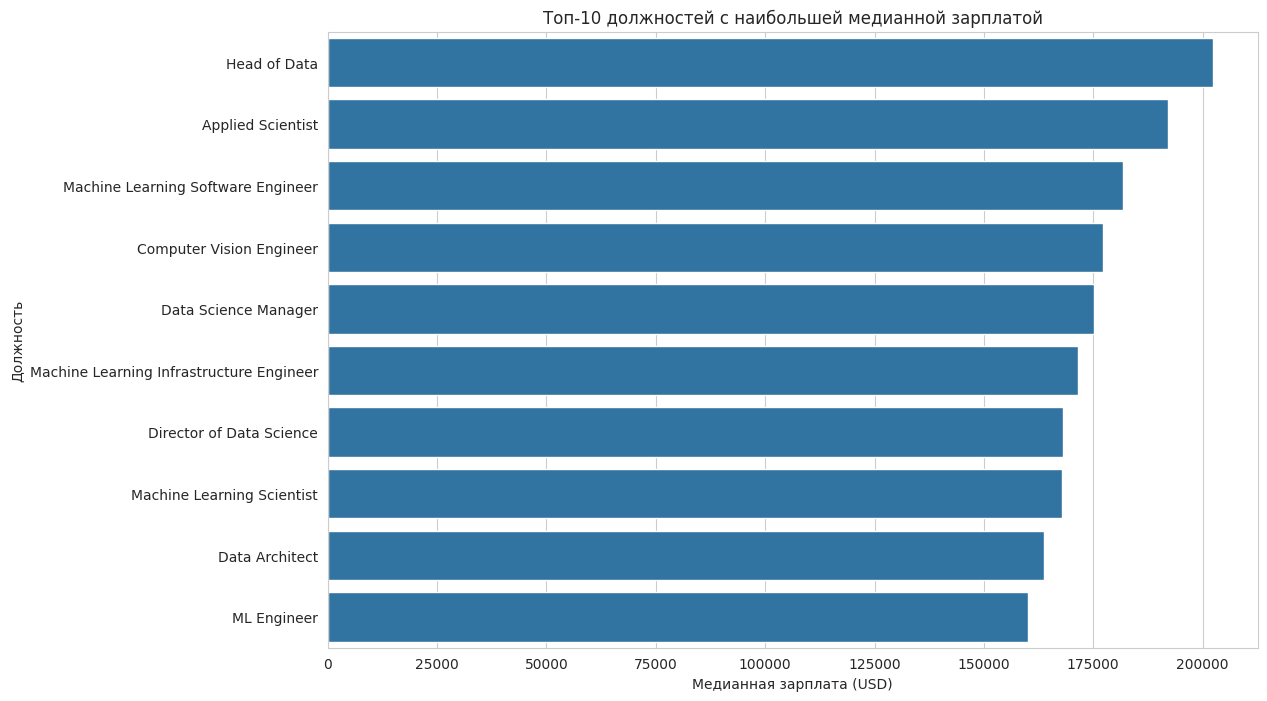

In [ ]:
top10 = median_salary_filtered.sort_values(by='median', ascending=False).head(10)

sns.barplot(data=top10.reset_index(), y='job_title', x='median')

plt.title('Топ-10 должностей c наибольшей медианной зарплатой')
plt.xlabel('Медианная зарплата (USD)')
plt.ylabel('Должность')

plt.show()

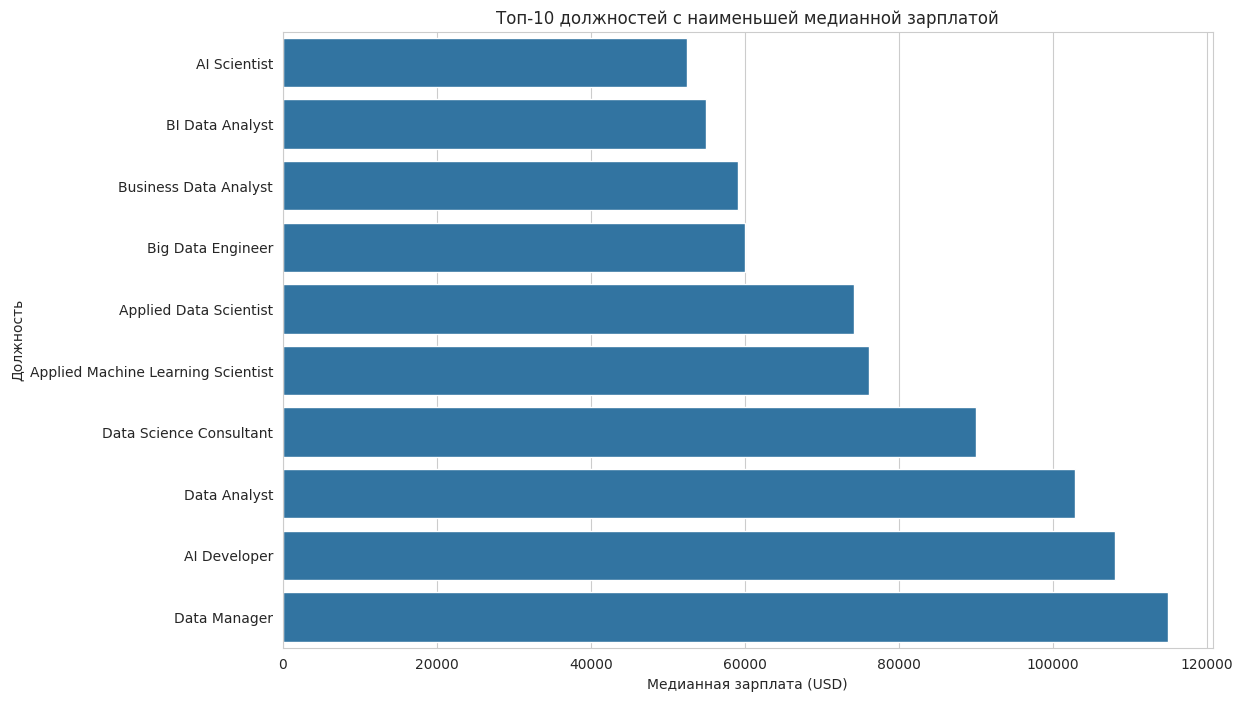

In [ ]:
bottom10 = median_salary_filtered.sort_values(by='median', ascending=True).head(10)

sns.barplot(data=bottom10.reset_index(),y='job_title',x='median')

plt.title('Топ-10 должностей с наименьшей медианной зарплатой')
plt.xlabel('Медианная зарплата (USD)')
plt.ylabel('Должность')

plt.show()

Анализ медианных заработных плат по должностям показал значительную дифференциацию доходов.

Наиболее высокие значения наблюдаются в руководящих и специализированных ролях, таких как Director of Data Science, Machine Learning Software Engineer и Applied Scientist.

В то же время менее высокие медианные значения характерны для начальных и менее специализированных позиций.

Использование медианы вместо среднего значения позволяет снизить влияние выбросов и получить более устойчивую оценку уровня заработной платы.

Также для повышения надёжности анализа были исключены должности с малым количеством наблюдений (менее 10).

## Анализ изменения заработных плат в 2023 году относительно 2020

In [ ]:
year_diff_filtered = df[df['work_year'].isin([2020,2023])]

In [ ]:
year_diff_filtered_table = pd.pivot_table(
    year_diff_filtered,
    index='job_title',
    columns='work_year',
    values='salary_in_usd',
    aggfunc='median'
)
year_diff_filtered_table = year_diff_filtered_table.dropna()
year_diff_filtered_table

work_year,2020,2023
job_title,,
AI Scientist,45896.0,231232.5
BI Data Analyst,98000.0,71897.0
Big Data Engineer,109024.0,89144.5
Business Data Analyst,100000.0,21461.0
Computer Vision Engineer,60000.0,212500.0
Data Analyst,34784.0,108000.0
Data Engineer,72134.5,145000.0
Data Science Consultant,54353.5,94000.0
Data Science Manager,190200.0,183382.5


In [ ]:
year_diff_filtered_table['growth'] = year_diff_filtered_table[2023] - year_diff_filtered_table[2020]
year_diff_filtered_table['growth']

,growth
job_title,
AI Scientist,185336.5
BI Data Analyst,-26103.0
Big Data Engineer,-19879.5
Business Data Analyst,-78539.0
Computer Vision Engineer,152500.0
Data Analyst,73216.0
Data Engineer,72865.5
Data Science Consultant,39646.5
Data Science Manager,-6817.5


In [ ]:
top_growth = year_diff_filtered_table.sort_values(by='growth', ascending=False).head(10)
top_growth

work_year,2020,2023,growth
job_title,,,
AI Scientist,45896.0,231232.5,185336.5
ML Engineer,15966.0,180000.0,164034.0
Computer Vision Engineer,60000.0,212500.0,152500.0
Machine Learning Infrastructure Engineer,50180.0,171600.0,121420.0
Data Scientist,62726.0,150000.0,87274.0
Data Analyst,34784.0,108000.0,73216.0
Data Engineer,72134.5,145000.0,72865.5
Data Science Consultant,54353.5,94000.0,39646.5
Machine Learning Engineer,144000.0,150450.0,6450.0


In [ ]:
top_decline = year_diff_filtered_table.sort_values(by='growth', ascending=True).head(10)
top_decline

work_year,2020,2023,growth
job_title,,,
Research Scientist,246000.0,150900.0,-95100.0
Business Data Analyst,100000.0,21461.0,-78539.0
Director of Data Science,325000.0,249300.0,-75700.0
Principal Data Scientist,148261.0,85847.0,-62414.0
Machine Learning Scientist,260000.0,210000.0,-50000.0
Lead Data Analyst,87000.0,43119.0,-43881.0
BI Data Analyst,98000.0,71897.0,-26103.0
Big Data Engineer,109024.0,89144.5,-19879.5
Data Science Manager,190200.0,183382.5,-6817.5


In [ ]:
# Динамика в процентах
year_diff_filtered_table['growth_pct'] = (
    (year_diff_filtered_table[2023] - year_diff_filtered_table[2020])
    / year_diff_filtered_table[2020] * 100
)

In [ ]:
top_growth_pct = year_diff_filtered_table.sort_values(by='growth_pct', ascending=False).head(10)
top_growth_pct

work_year,2020,2023,growth,growth_pct
job_title,,,,
ML Engineer,15966.0,180000.0,164034.0,1027.395716
AI Scientist,45896.0,231232.5,185336.5,403.818416
Computer Vision Engineer,60000.0,212500.0,152500.0,254.166667
Machine Learning Infrastructure Engineer,50180.0,171600.0,121420.0,241.968912
Data Analyst,34784.0,108000.0,73216.0,210.487580
Data Scientist,62726.0,150000.0,87274.0,139.135287
Data Engineer,72134.5,145000.0,72865.5,101.013385
Data Science Consultant,54353.5,94000.0,39646.5,72.941945
Product Data Analyst,13036.0,16414.0,3378.0,25.912857


In [ ]:
top_decline_pct = year_diff_filtered_table.sort_values(by='growth_pct', ascending=True).head(10)
top_decline_pct

work_year,2020,2023,growth,growth_pct
job_title,,,,
Business Data Analyst,100000.0,21461.0,-78539.0,-78.539000
Lead Data Analyst,87000.0,43119.0,-43881.0,-50.437931
Principal Data Scientist,148261.0,85847.0,-62414.0,-42.097382
Research Scientist,246000.0,150900.0,-95100.0,-38.658537
BI Data Analyst,98000.0,71897.0,-26103.0,-26.635714
Director of Data Science,325000.0,249300.0,-75700.0,-23.292308
Machine Learning Scientist,260000.0,210000.0,-50000.0,-19.230769
Big Data Engineer,109024.0,89144.5,-19879.5,-18.234059
Data Science Manager,190200.0,183382.5,-6817.5,-3.584385


In [ ]:
# процент должностей с увеличением заработка
(year_diff_filtered_table['growth'] > 0).mean()

np.float64(0.5263157894736842)

Анализ динамики медианных заработных плат в период с 2020 по 2023 год показал, что рост наблюдается примерно в 53% должностей, что указывает на умеренно положительную динамику рынка в целом.

Наиболее значительное увеличение заработных плат зафиксировано в технических и AI-ориентированных ролях, таких как ML Engineer, AI Scientist и Computer Vision Engineer. Это отражает усиление спроса на специалистов в области машинного обучения и искусственного интеллекта. При этом экстремально высокие темпы роста частично объясняются эффектом низкой базы в 2020 году.

В то же время ряд позиций, включая Business Data Analyst, Lead Data Analyst и Principal Data Scientist, демонстрирует снижение заработных плат. Снижение также затрагивает некоторые управленческие роли, что может свидетельствовать о перераспределении спроса в пользу специалистов с более выраженной технической экспертизой.

В целом, результаты показывают, что рынок Data Science развивается неравномерно: наибольшую выгоду получают специалисты в области AI/ML, тогда как часть аналитических и управленческих позиций сталкивается со стагнацией или снижением доходов.

## Портрет наиболее успешного специалиста Data Science

In [ ]:
df['salary_in_usd'].quantile(0.95)

np.float64(249469.99999999997)

In [ ]:
threshold = df['salary_in_usd'].quantile(0.95)
df_top = df[df['salary_in_usd'] >= threshold]
df_top

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_name,employment_type_name,company_size_name,company_location_name,employee_residence_name
21,2023,SE,FT,Research Engineer,275000,USD,275000,DE,0,DE,M,Senior,Full-time,Medium,Germany,Germany
31,2023,SE,FT,Data Engineer,253200,USD,253200,US,0,US,M,Senior,Full-time,Medium,United States,United States
33,2023,SE,FT,Computer Vision Engineer,342810,USD,342810,US,0,US,M,Senior,Full-time,Medium,United States,United States
44,2023,SE,FT,Data Engineer,270703,USD,270703,US,0,US,M,Senior,Full-time,Medium,United States,United States
48,2023,SE,FT,Data Scientist,262000,USD,262000,US,100,US,M,Senior,Full-time,Medium,United States,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3615,2021,SE,FT,ML Engineer,256000,USD,256000,US,100,US,S,Senior,Full-time,Small,United States,United States
3675,2021,EX,CT,Principal Data Scientist,416000,USD,416000,US,100,US,S,Executive,Contract,Small,United States,United States
3697,2020,EX,FT,Director of Data Science,325000,USD,325000,US,100,US,L,Executive,Full-time,Large,United States,United States
3747,2021,MI,FT,Applied Machine Learning Scientist,423000,USD,423000,US,50,US,L,Middle,Full-time,Large,United States,United States


In [ ]:
df_top['job_title'].value_counts().head(10)

,count
job_title,
Data Engineer,32
Data Scientist,20
Machine Learning Engineer,18
Research Scientist,7
Data Architect,6
Data Science Manager,5
Applied Scientist,4
Research Engineer,4
ML Engineer,4


In [ ]:
df_top['experience_level_name'].value_counts()

,count
experience_level_name,
Senior,99
Executive,18
Middle,11
Junior,2


In [ ]:
df_top['company_location_name'].value_counts().head()

,count
company_location_name,
United States,118
Canada,4
Germany,2
India,1
Israel,1


In [ ]:
df_top['remote_ratio'].value_counts()

,count
remote_ratio,
0,77
100,48
50,5


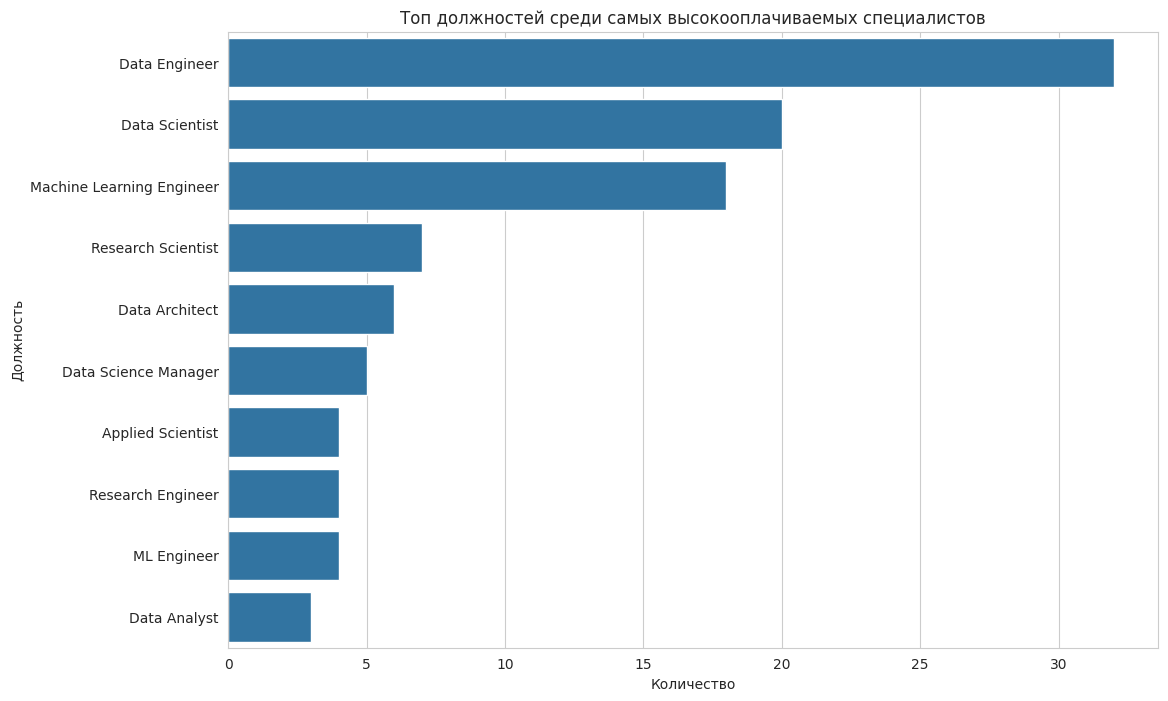

In [ ]:
top_jobs = df_top['job_title'].value_counts().head(10)

sns.barplot(x=top_jobs.values, y=top_jobs.index)

plt.title('Топ должностей среди самых высокооплачиваемых специалистов')
plt.xlabel('Количество')
plt.ylabel('Должность')

plt.show()

In [ ]:
# Доля США в датасете
(df['company_location'] == 'US').mean()

np.float64(0.746517027863777)

In [ ]:
# Доля США среди топа
(df_top['company_location'] == 'US').mean()

np.float64(0.9076923076923077)

Анализ топ-5% самых высокооплачиваемых специалистов показал, что типичный “успешный” работник в сфере Data Science — это специалист технического профиля, чаще всего занимающий позиции Data Engineer, Data Scientist или Machine Learning Engineer.

Подавляющее большинство таких специалистов имеет уровень Senior, что подтверждает ключевую роль опыта в достижении высокого дохода.

Географически высокие зарплаты сконцентрированы в США: около 91% топовых специалистов работают в американских компаниях, что значительно выше их доли в общей выборке (~75%).

Формат работы не является определяющим фактором: среди наиболее высокооплачиваемых специалистов преобладает офисный формат, однако доля полностью удалённых сотрудников также остаётся значительной.

Таким образом, портрет самого успешного специалиста — это Senior специалист технической роли (Data/ML), работающий в США, при этом формат работы может быть как офисным, так и удалённым.

## Анализ международной занятости и удалённой работы

In [ ]:
(df['employee_residence'] != df['company_location']).mean()

np.float64(0.03715170278637771)

In [ ]:
df['employee_residence_name'].value_counts().head()

,count
employee_residence_name,
United States,1893
United Kingdom,150
Canada,81
India,70
Germany,47


In [ ]:
df_diff = df[df['employee_residence'] != df['company_location']]

In [ ]:
df_diff['remote_ratio'].value_counts(normalize=True)

,proportion
remote_ratio,
100,0.739583
50,0.187500
0,0.072917


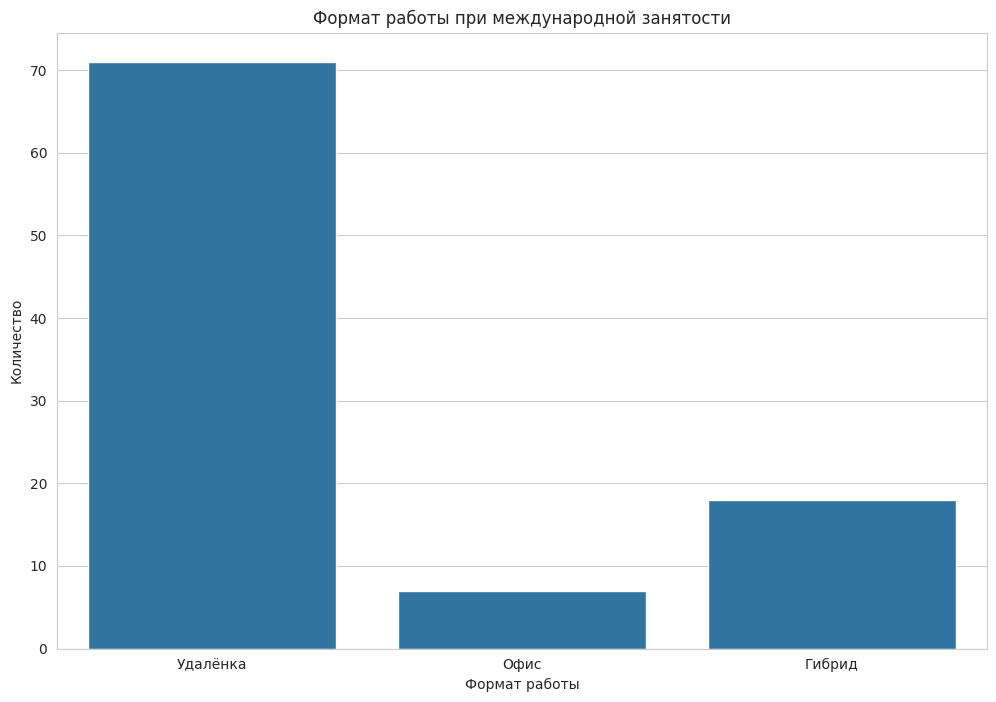

In [ ]:
sns.countplot(
    x=df_diff['remote_ratio'].map({0: 'Офис', 50: 'Гибрид', 100: 'Удалёнка'})
)

plt.title('Формат работы при международной занятости')
plt.xlabel('Формат работы')
plt.ylabel('Количество')

plt.show()

Анализ показал, что доля специалистов, работающих на компании, расположенные в другой стране, составляет около 3–4%, что указывает на относительно низкую распространённость международной занятости в датасете.

Наибольшее количество специалистов проживает в США, Великобритании, Канаде, Индии и Германии, что отражает географию основных рынков Data Science.

При этом среди специалистов, работающих на зарубежные компании, подавляющее большинство (около 74%) работают полностью удалённо, тогда как доля офисных сотрудников минимальна (~7%).

Это свидетельствует о том, что международная занятость в Data Science практически полностью реализуется через удалённый формат работы, который выступает ключевым механизмом взаимодействия между специалистами и компаниями из разных стран.

## Общие выводы

В ходе проведённого анализа были выявлены ключевые закономерности, влияющие на уровень заработной платы специалистов в области Data Science.

Прежде всего, основным фактором, определяющим уровень дохода, является опыт специалиста. Наблюдается устойчивый рост заработной платы при переходе от начальных позиций к более высоким уровням квалификации.

Формат занятости (удалённый, гибридный или офисный) не оказывает существенного влияния на уровень заработной платы при учёте уровня опыта. Это позволяет сделать вывод о том, что различия, наблюдаемые на агрегированном уровне, в значительной степени обусловлены распределением специалистов по уровням квалификации.

Размер компании также демонстрирует связь с уровнем заработной платы: сотрудники средних компаний в среднем зарабатывают больше, чем сотрудники малых и крупных организаций. Данная особенность может быть связана с активным ростом таких компаний и их стремлением привлекать квалифицированных специалистов.

Географический фактор играет значительную роль: уровень заработной платы существенно различается в зависимости от страны. Наиболее высокие значения наблюдаются в странах с развитым рынком технологий, что отражает глобальное распределение спроса на специалистов в области Data Science.

Таким образом, можно заключить, что ключевыми драйверами уровня заработной платы являются опыт специалиста и страна работы, в то время как формат занятости оказывает второстепенное влияние.

## Дополнительные инсайты

### Концентрация высоких зарплат в США

Доля специалистов, работающих в компаниях США, среди топ-5% самых высокооплачиваемых сотрудников составляет около 91%, тогда как в общей выборке — около 75%. Это указывает на непропорциональную концентрацию высоких доходов на американском рынке и подчёркивает важность географического фактора.

### Смещение рынка в сторону AI/ML

Наибольший рост заработных плат наблюдается в ролях, связанных с машинным обучением и искусственным интеллектом, таких как ML Engineer и AI Scientist. Это отражает текущий технологический тренд и рост спроса на специалистов с глубокими техническими навыками.

### Удалённая работа не гарантирует более высокую зарплату

Анализ показал, что различия в заработной плате между удалённым и офисным форматом работы в значительной степени обусловлены уровнем опыта специалистов. При сравнении внутри одного уровня (например, Senior) существенной разницы в оплате не наблюдается.

### Удалённая работа как механизм международной занятости

Хотя доля специалистов, работающих на компании из других стран, составляет всего около 3–4%, среди них подавляющее большинство (~74%) работают полностью удалённо. Это свидетельствует о том, что удалённый формат является ключевым инструментом международного взаимодействия на рынке Data Science.

### Высокие доходы достигаются за счёт технической экспертизы

Среди наиболее высокооплачиваемых специалистов преобладают не только управленческие роли, но и технические позиции, такие как Data Engineer и Machine Learning Engineer. Это указывает на то, что глубокая техническая экспертиза является важным фактором достижения высокого уровня дохода.